# **Final Project**

## **1. Import necessary libraries and fetch the data**




In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn import datasets, linear_model, metrics
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, classification_report, roc_curve, RocCurveDisplay, auc, precision_recall_curve, PrecisionRecallDisplay, average_precision_score
from sklearn.model_selection import cross_val_score
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.offline as py
%matplotlib inline

File_path = "/content/Car_Insurance_Claim.csv"
df = pd.read_csv(File_path)
df.head()

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [ ]:
df.shape

(10000, 19)

This dataset has 10,000 rows and 19 columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  object 
 2   GENDER               10000 non-null  object 
 3   RACE                 10000 non-null  object 
 4   DRIVING_EXPERIENCE   10000 non-null  object 
 5   EDUCATION            10000 non-null  object 
 6   INCOME               10000 non-null  object 
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  object 
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  object 
 15  SPEEDING_VIOLATIONS  10000 non-null  

## **2. Exploratory data analysis**

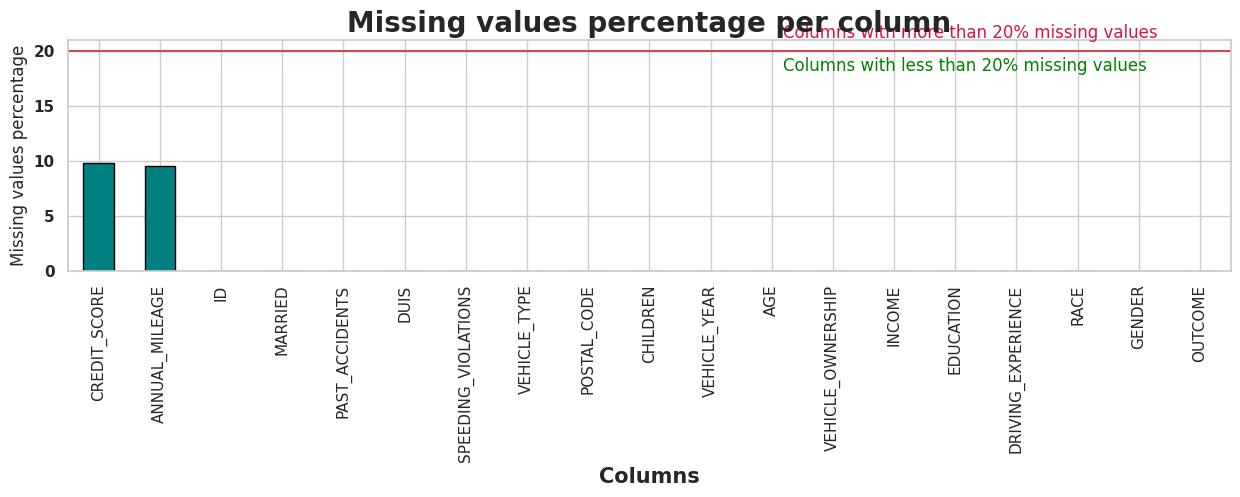

In [ ]:
def msv_1(df, thresh = 20, color = 'black', edgecolor = 'black', height = 3, width = 15):

    plt.figure(figsize = (width, height))
    percentage = (df.isnull().mean()) * 100
    percentage.sort_values(ascending = False).plot.bar(color = 'teal', edgecolor = edgecolor)
    plt.axhline(y = thresh, color = 'r', linestyle = '-')

    plt.title('Missing values percentage per column', fontsize=20, weight='bold' )

    plt.text(len(df.isnull().sum()/len(df))/1.7, thresh+2.5, f'Columns with more than {thresh}% missing values', fontsize=12, color='crimson',
         ha='left' ,va='top')
    plt.text(len(df.isnull().sum()/len(df))/1.7, thresh - 0.5, f'Columns with less than {thresh}% missing values', fontsize=12, color='green',
         ha='left' ,va='top')
    plt.xlabel('Columns', size=15, weight='bold')
    plt.ylabel('Missing values percentage')
    plt.yticks(weight ='bold')

    return plt.show()
msv_1(df, 20, color=sns.color_palette('Reds',15))

There are 2 columns in car insurance dataset with missing values.

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
CREDIT_SCORE,982
ANNUAL_MILEAGE,957
ID,0
MARRIED,0
PAST_ACCIDENTS,0
DUIS,0
SPEEDING_VIOLATIONS,0
VEHICLE_TYPE,0
POSTAL_CODE,0
CHILDREN,0


### **2.1 Setting up the AGE column**

In [ ]:
df['AGE'].value_counts()

,count
AGE,
26-39,3063
40-64,2931
16-25,2016
65+,1990


In [ ]:
def preprocess_age(age):
    if age == '65+':
        return 'very_old'
    elif age == '40-64':
        return 'old'
    elif age == '26-39':
        return 'middle_age'
    elif age == '16-25':
        return 'young'
    else:
        return None

df['AGE'] = df['AGE'].apply(preprocess_age)

Modifying experience accordingly:

In [ ]:
df['DRIVING_EXPERIENCE'].value_counts()

,count
DRIVING_EXPERIENCE,
0-9y,3530
10-19y,3299
20-29y,2119
30y+,1052


In [ ]:
def preprocess_experience(exp):
    if exp == '0-9y':
        return 'novice'
    elif exp == '10-19y':
        return 'intermediate'
    elif exp == '20-29y':
        return 'experienced'
    elif exp == '30y+':
        return 'expert'

df['DRIVING_EXPERIENCE'] = df['DRIVING_EXPERIENCE'].apply(preprocess_experience)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  object 
 2   GENDER               10000 non-null  object 
 3   RACE                 10000 non-null  object 
 4   DRIVING_EXPERIENCE   10000 non-null  object 
 5   EDUCATION            10000 non-null  object 
 6   INCOME               10000 non-null  object 
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  object 
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  object 
 15  SPEEDING_VIOLATIONS  10000 non-null  

### **2.2 Data exploration**

In [ ]:
df.OUTCOME.value_counts()

,count
OUTCOME,
0.0,6867
1.0,3133


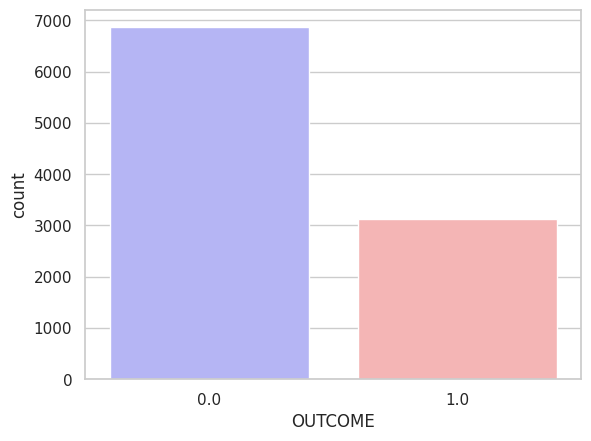

In [ ]:
sns.countplot(x="OUTCOME", data=df, palette="bwr")
plt.show()

In [ ]:
dont_claim_loan = len(df[df.OUTCOME == 1])
claim_loan = len(df[df.OUTCOME == 0])
print("Percentage of people who apply for a loan: {:.2f}%".format((dont_claim_loan / (len(df.OUTCOME))*100)))
print("Percentage of people who did not apply for a loan: {:.2f}%".format((claim_loan / (len(df.OUTCOME))*100)))

Percentage of people who apply for a loan: 31.33%
Percentage of people who did not apply for a loan: 68.67%


We have 31.33% persons who apply for a loan; And the 68.67% persons who did not apply for a loan, so our problem is somewhat imbalanced.

array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'CREDIT_SCORE'}>,
        <Axes: title={'center': 'VEHICLE_OWNERSHIP'}>],
       [<Axes: title={'center': 'MARRIED'}>,
        <Axes: title={'center': 'CHILDREN'}>,
        <Axes: title={'center': 'POSTAL_CODE'}>],
       [<Axes: title={'center': 'ANNUAL_MILEAGE'}>,
        <Axes: title={'center': 'SPEEDING_VIOLATIONS'}>,
        <Axes: title={'center': 'DUIS'}>],
       [<Axes: title={'center': 'PAST_ACCIDENTS'}>,
        <Axes: title={'center': 'OUTCOME'}>, <Axes: >]], dtype=object)

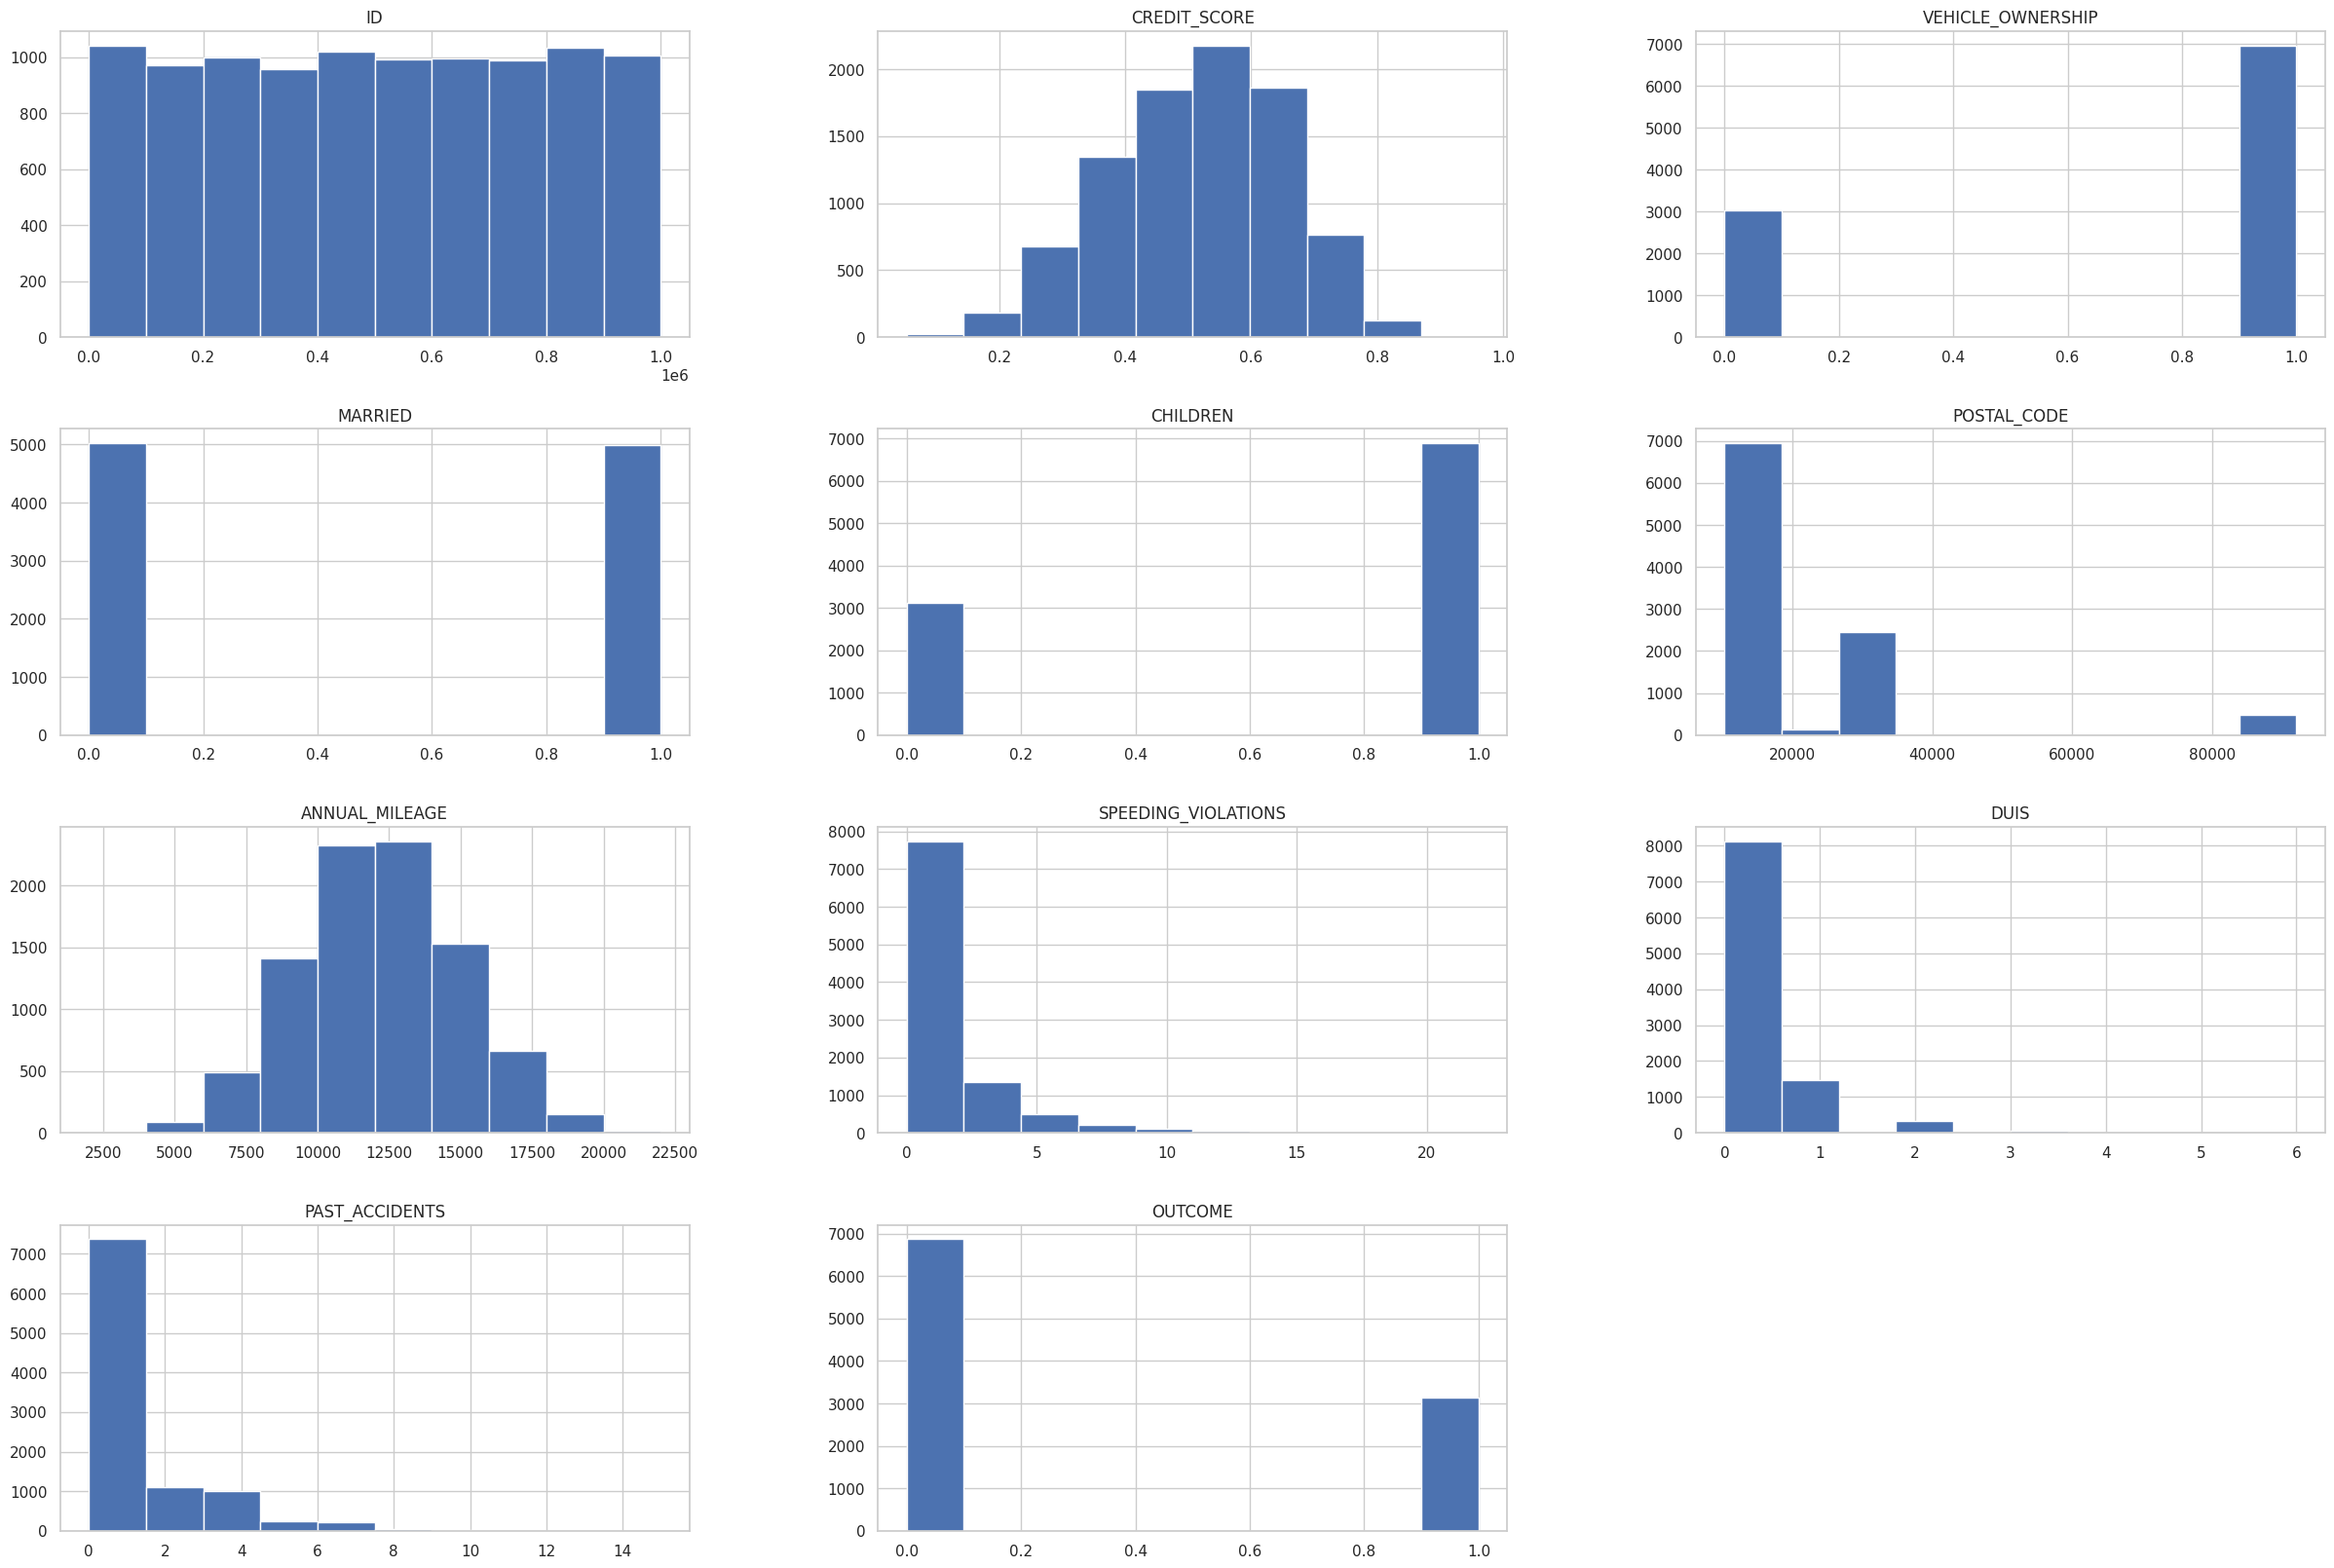

In [ ]:
df.hist(figsize=(30,20))

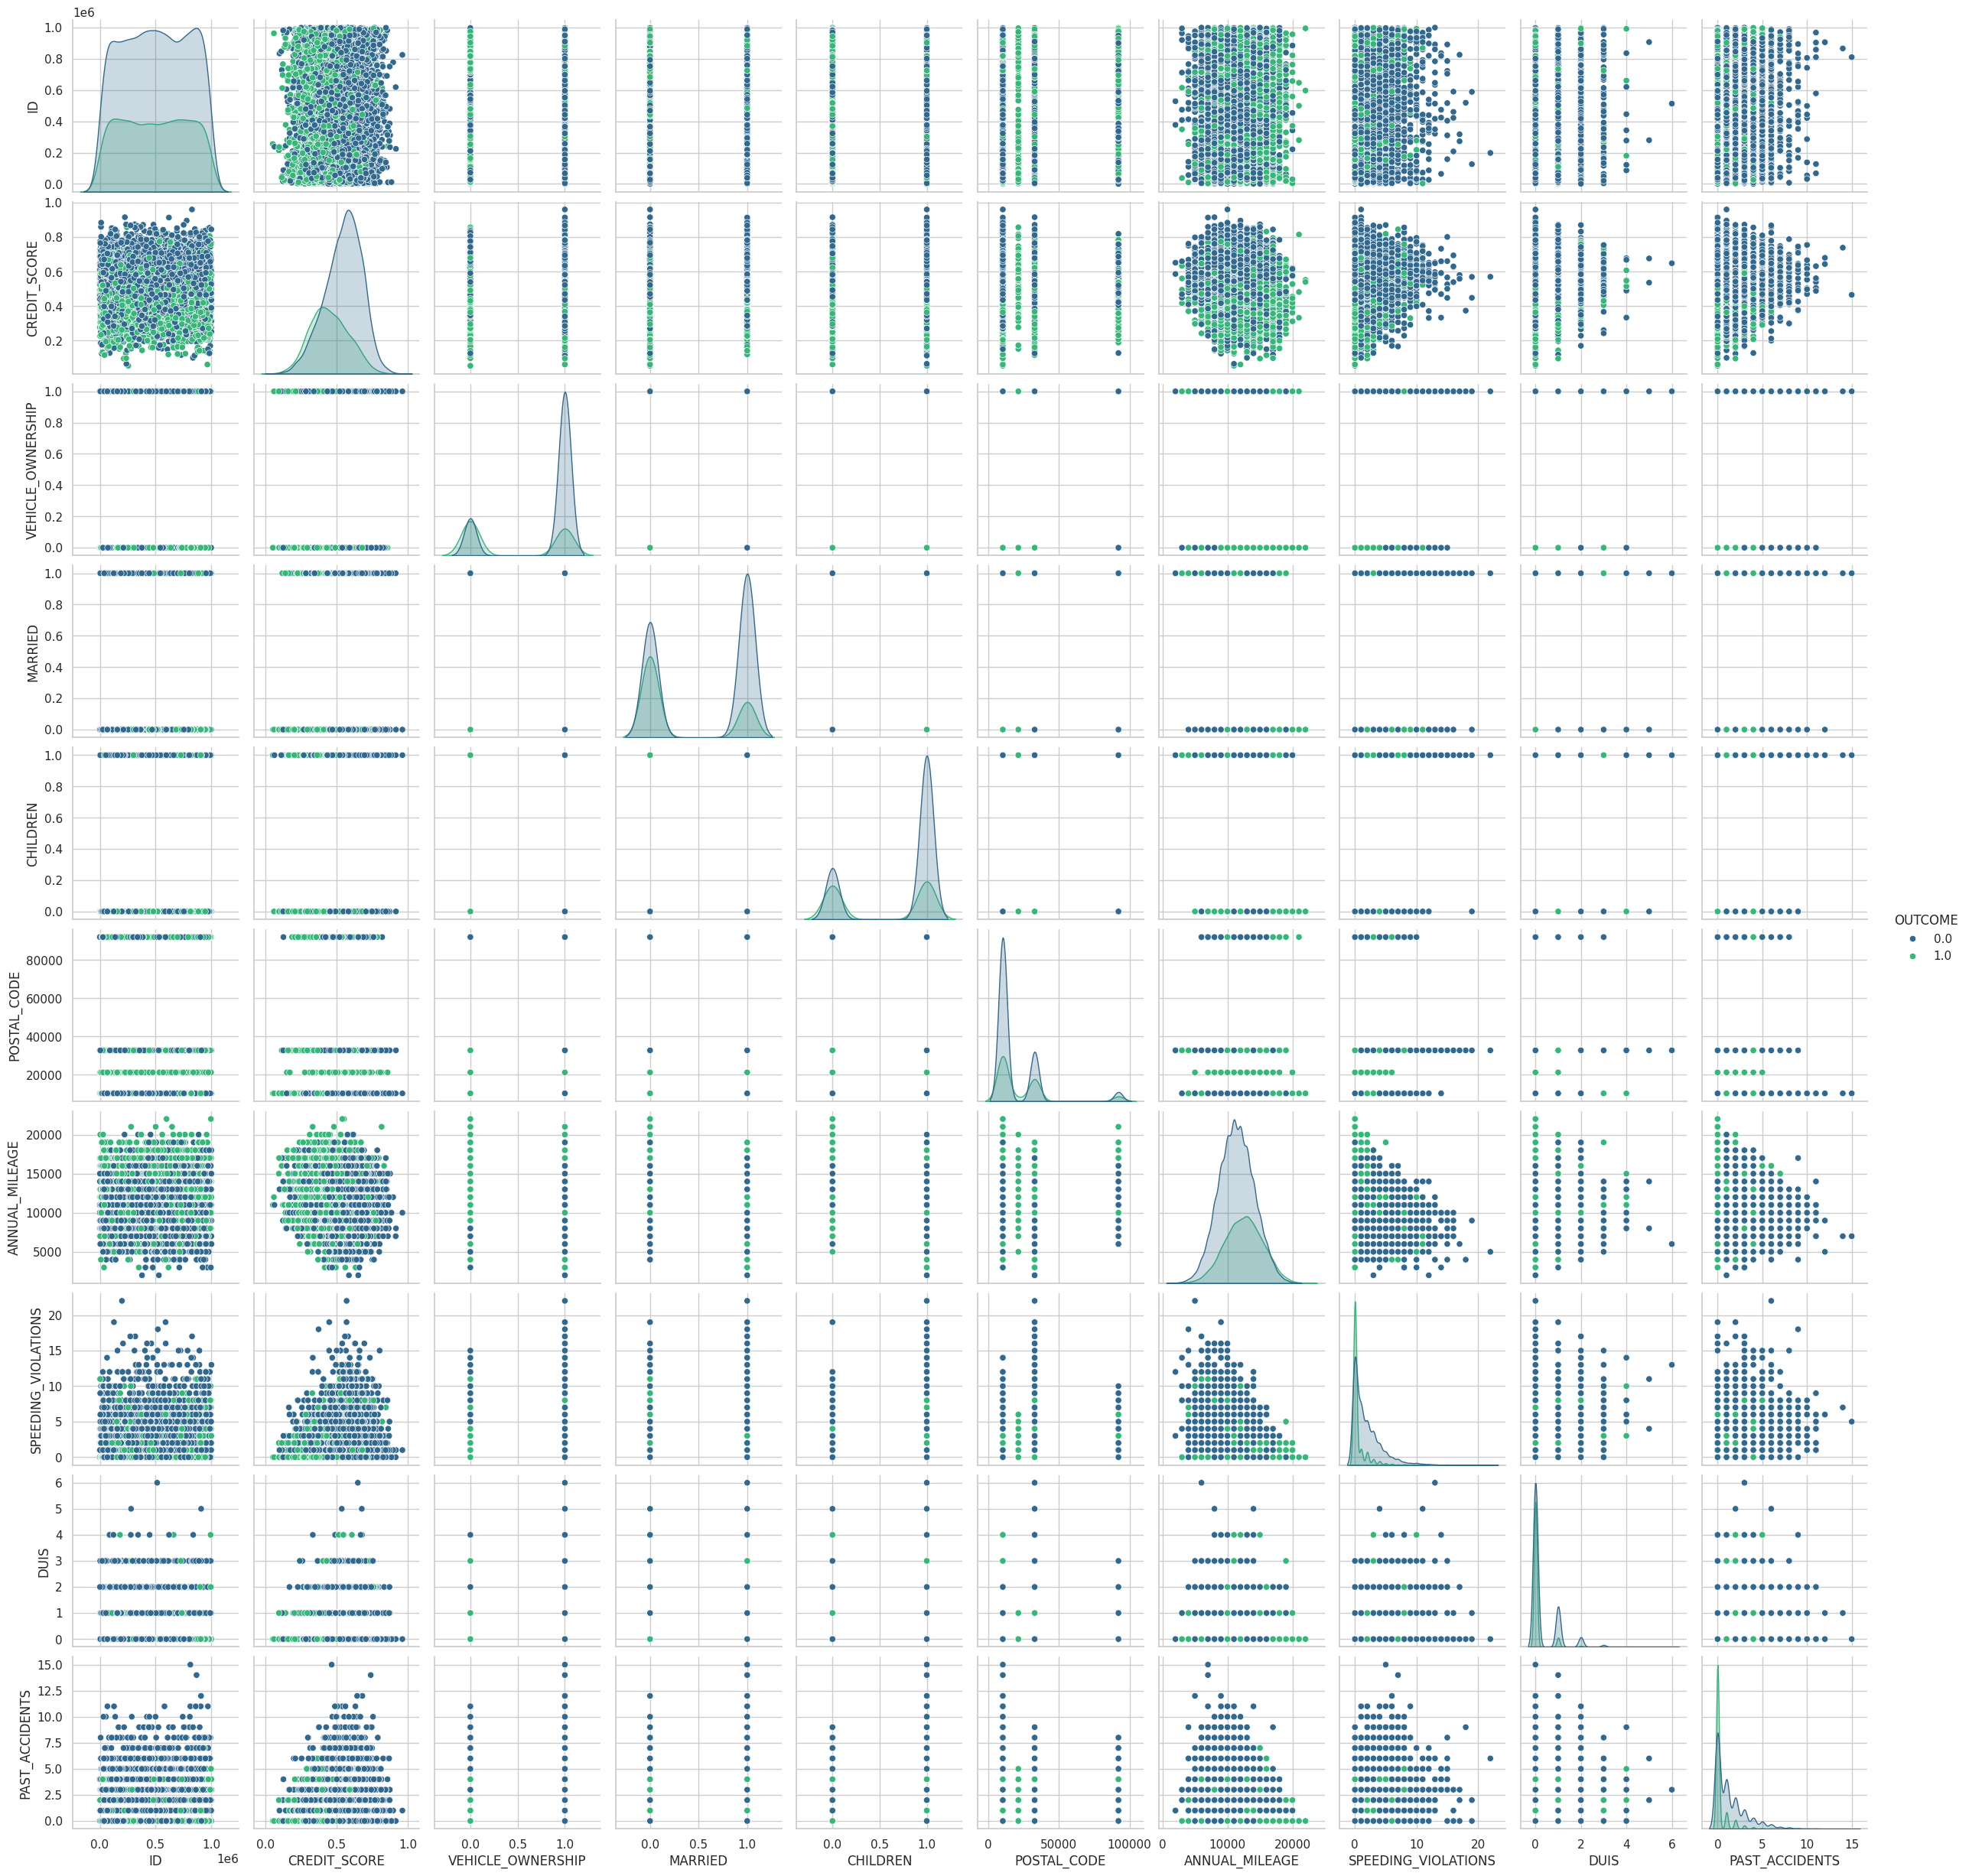

In [ ]:
sns.pairplot(df, hue="OUTCOME", palette="viridis");

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

categorical_columns = ['AGE','DRIVING_EXPERIENCE','GENDER', 'RACE', 'EDUCATION', 'INCOME', 'VEHICLE_YEAR', 'VEHICLE_TYPE']
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df_corr = df_encoded.corr()

print(df_corr)

                           ID       AGE    GENDER      RACE  \
ID                   1.000000 -0.007090 -0.007343 -0.005973   
AGE                 -0.007090  1.000000 -0.011848 -0.003741   
GENDER              -0.007343 -0.011848  1.000000 -0.006711   
RACE                -0.005973 -0.003741 -0.006711  1.000000   
DRIVING_EXPERIENCE  -0.004543  0.200107 -0.007397  0.018072   
EDUCATION           -0.008880 -0.038837  0.082831 -0.041897   
INCOME              -0.006655  0.020125  0.012226 -0.000151   
CREDIT_SCORE         0.001704 -0.119291 -0.081587 -0.039359   
VEHICLE_OWNERSHIP    0.009197 -0.064985  0.007385 -0.034738   
VEHICLE_YEAR         0.003281  0.035483 -0.010674  0.020895   
MARRIED              0.014826 -0.073242  0.008393 -0.021597   
CHILDREN             0.001233 -0.101739 -0.002640  0.007575   
POSTAL_CODE          0.006038  0.004546 -0.001996  0.004655   
ANNUAL_MILEAGE      -0.002217  0.061425 -0.015845 -0.001983   
VEHICLE_TYPE         0.006243 -0.018296 -0.000022  0.00

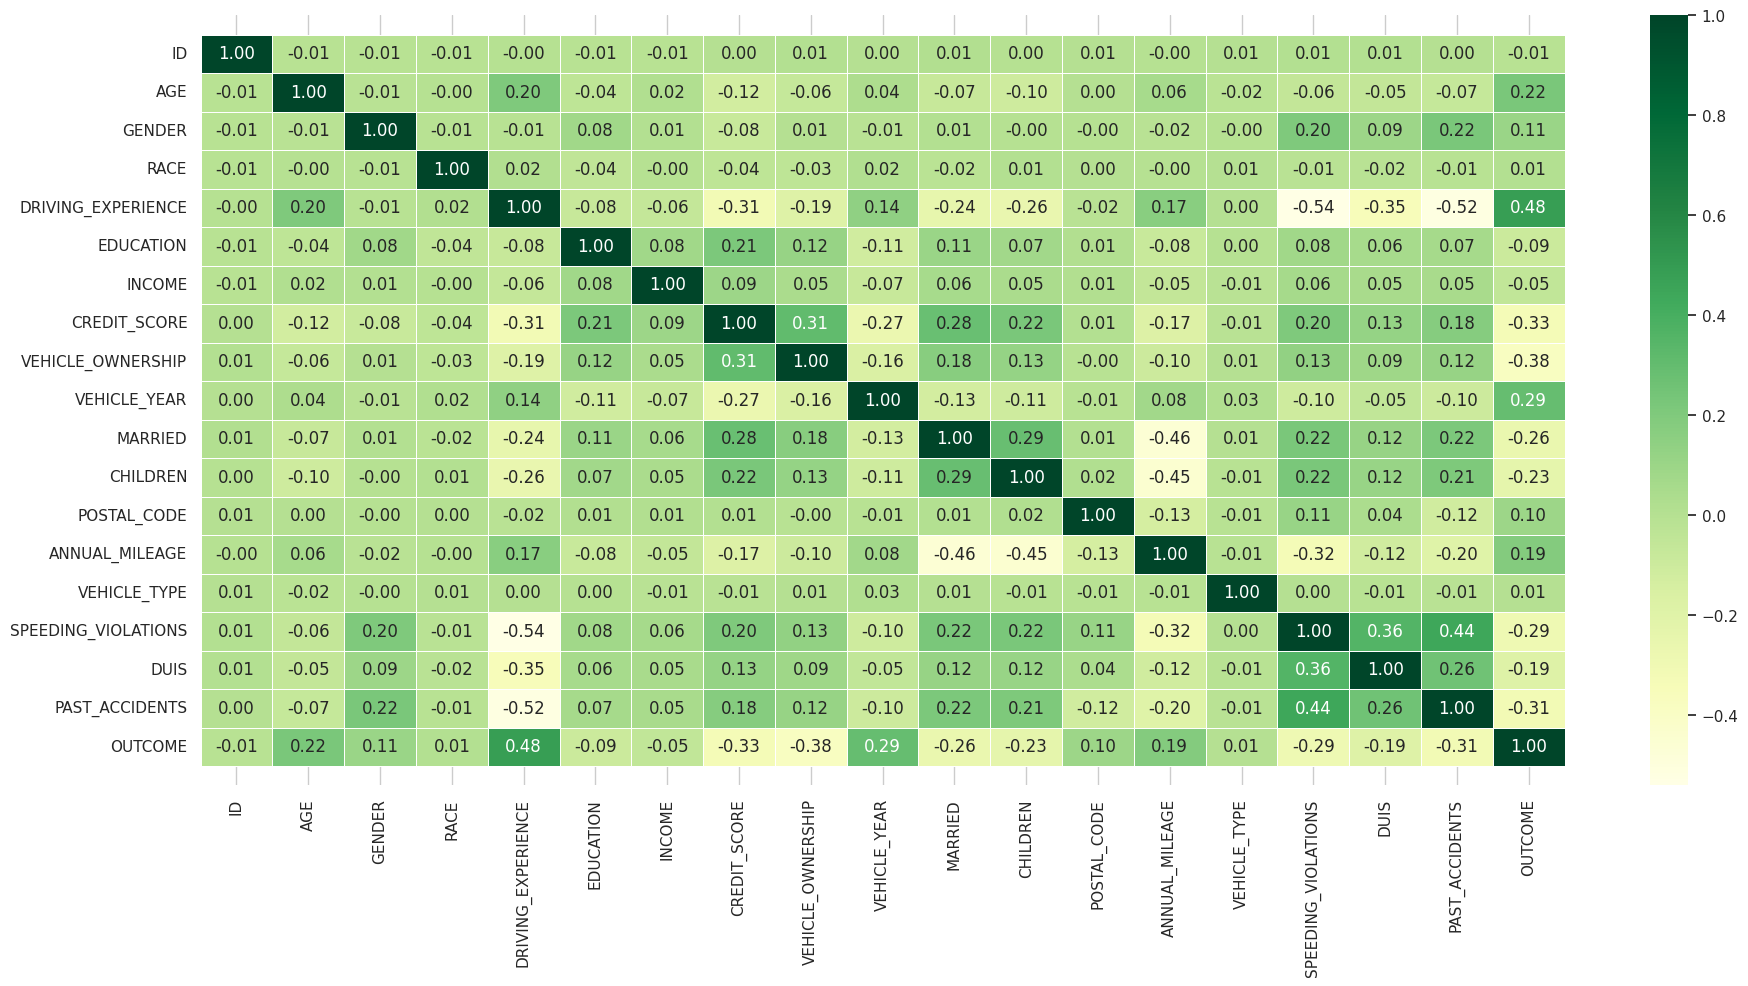

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
categorical_columns = df_encoded.select_dtypes(include=['object', 'category']).columns

for col in categorical_columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

corr_matrix = df_encoded.corr()
fig, ax = plt.subplots(figsize=(22, 10))
sns.heatmap(corr_matrix, annot=True, linewidths=0.5, fmt=".2f", cmap="YlGn", ax=ax)

bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.show()


<Axes: title={'center': 'Correlation with OUTCOME'}>

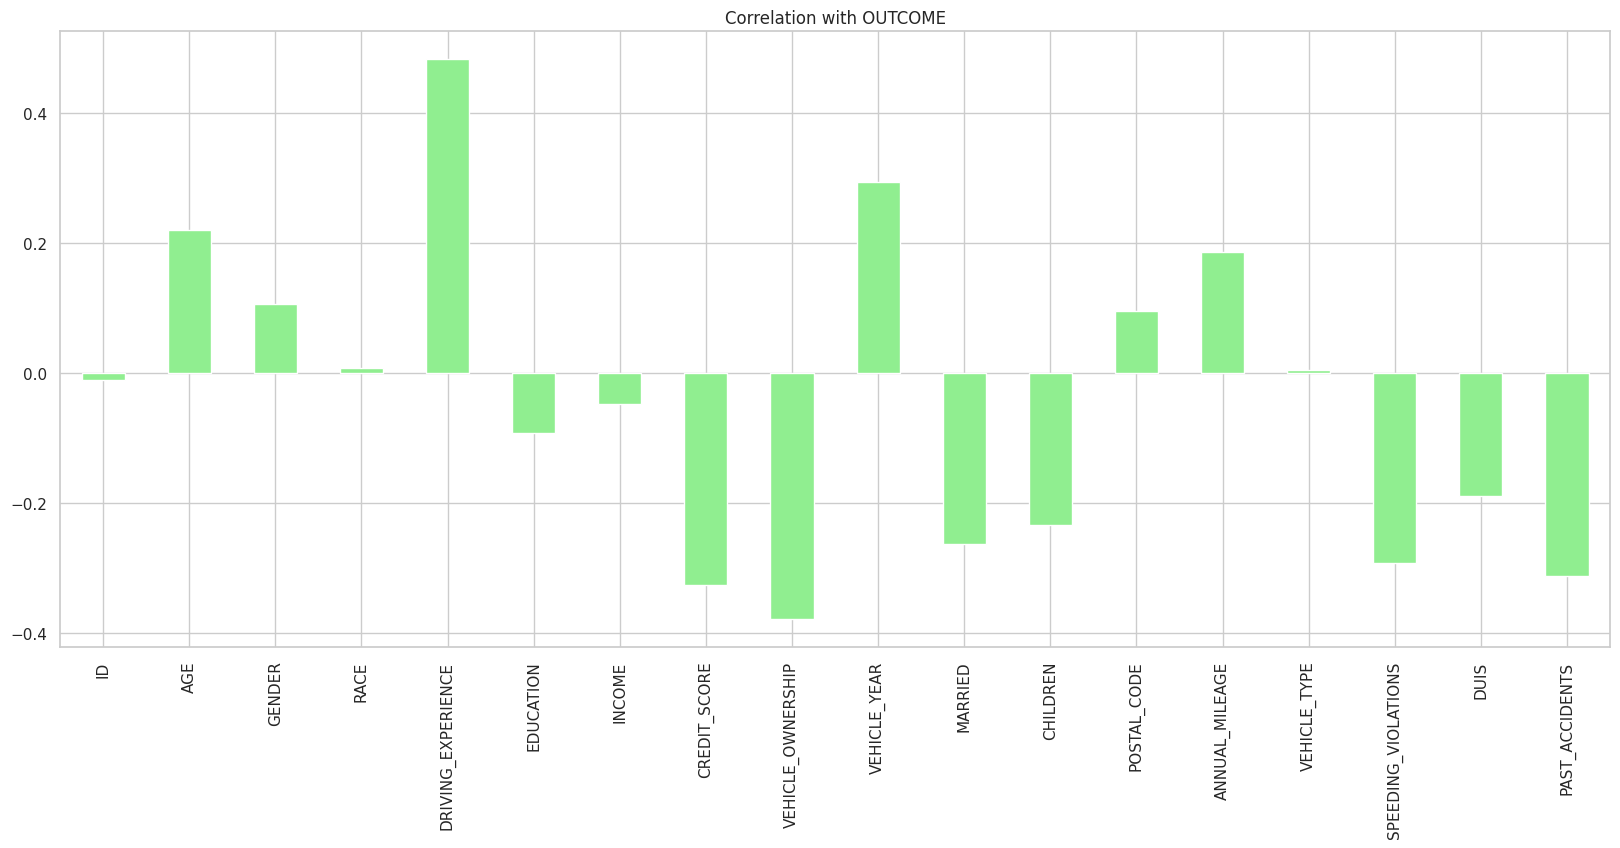

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
categorical_columns = df_encoded.select_dtypes(include=['object', 'category']).columns

for col in categorical_columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.drop('OUTCOME', axis=1).corrwith(df_encoded.OUTCOME).plot(
    kind='bar',
    grid=True,
    figsize=(20, 8),
    title="Correlation with OUTCOME",
    color="lightgreen"
)


Observations from correlation:

VEHICLE_TYPE, ID are the least correlated with the OUTCOME variable.

VEHICLE_YEAR, DRIVING_EXPERIENCE, AGE, VEHICLE_OWNERSHIP are the most correlated with the OUTCOME variable.

**Relationship Between Age vs OUTCOME**

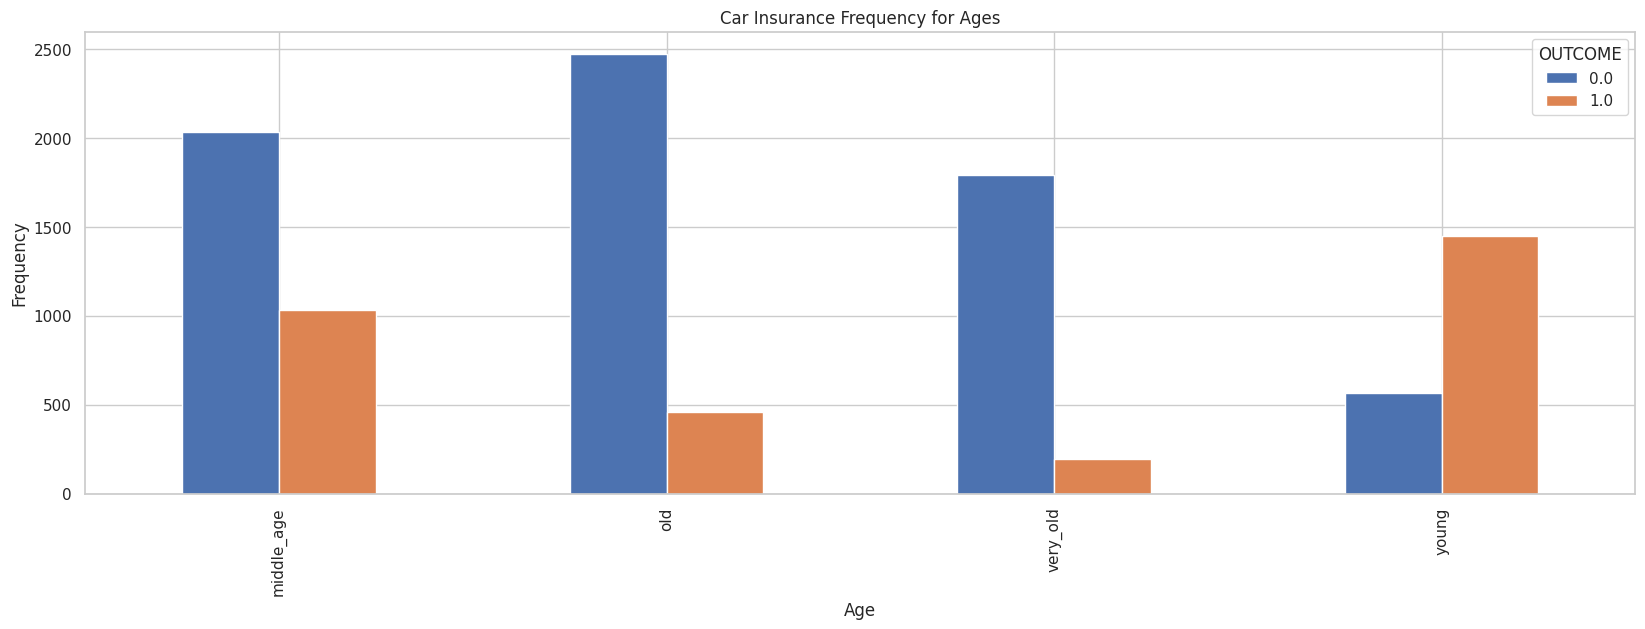

In [ ]:
pd.crosstab(df.AGE,df.OUTCOME).plot(kind="bar",figsize=(20,6))
plt.title('Car Insurance Frequency for Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Here, we see that young people are more likely to claim insurance.

In [ ]:
pd.crosstab(df["OUTCOME"], df["AGE"])

AGE,middle_age,old,very_old,young
OUTCOME,,,,
0.0,2031,2474,1794,568
1.0,1032,457,196,1448


We see that middle_age and old people are impacted the most

**Relationship Between DRIVING_EXPERIENCE vs OUTCOME**

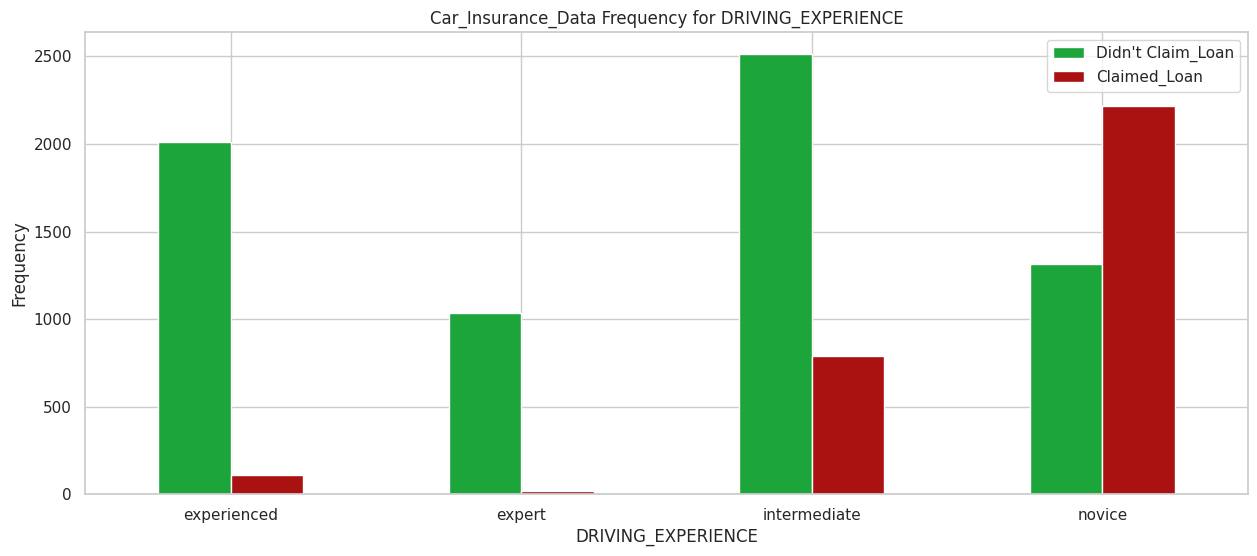

In [ ]:
pd.crosstab(df.DRIVING_EXPERIENCE,df.OUTCOME).plot(kind="bar",figsize=(15,6),color=['#1CA53B','#AA1111', '#FFA500' ])
plt.title('Car_Insurance_Data Frequency for DRIVING_EXPERIENCE')
plt.xlabel('DRIVING_EXPERIENCE')
plt.xticks(rotation=0)
plt.legend(["Didn't Claim_Loan", "Claimed_Loan"])
plt.ylabel('Frequency')
plt.show()

In [ ]:
pd.crosstab(df["OUTCOME"], df["DRIVING_EXPERIENCE"])

DRIVING_EXPERIENCE,experienced,expert,intermediate,novice
OUTCOME,,,,
0.0,2010,1032,2512,1313
1.0,109,20,787,2217


From this we can infer that novice driver's are highly likely to claim insurance

## **3. Preprocessing**

### **3.1 Data cleaning**

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
CREDIT_SCORE,982
ANNUAL_MILEAGE,957
ID,0
MARRIED,0
PAST_ACCIDENTS,0
DUIS,0
SPEEDING_VIOLATIONS,0
VEHICLE_TYPE,0
POSTAL_CODE,0
CHILDREN,0


In [ ]:
def fillna(dataframe,feature_cols):
    total_cols=0
    for y in feature_cols:
        total_cols+=1
        if dataframe[y].isna().sum()>1:
            try:
                dataframe[y]=dataframe[y].fillna(int(np.mean(dataframe[y])))
            except ValueError:
                pass
        else:
            continue

feature_cols=["CREDIT_SCORE","ANNUAL_MILEAGE"]
fillna(df,feature_cols)

Filled in missing data

### **3.2 Split Data**

In [ ]:
X = df.drop(['OUTCOME','ID'], axis=1)
y = df['OUTCOME']
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
counter = Counter(y_train)
print(counter)

Counter({0.0: 5500, 1.0: 2500})


The distribution of observations in the target class is skewed (imbalanced data).

### **3.3 Feature Scaling**

In [ ]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

### **3.4 Sampling**

In [ ]:
oversample = SMOTE(random_state=33)
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [ ]:
counter = Counter(y_train)
print(counter)

Counter({0.0: 5500, 1.0: 5500})


Now the data is Balanced

## **4. HyperParameter Tuning**

### **4.1 Tuning the models**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
grid_models = [(LogisticRegression(),[{'C':[0.25,0.5,0.75,1],'random_state':[0]}]),
               (GaussianNB(),[{'var_smoothing': [1e-09]}]),
               (DecisionTreeClassifier(),[{'criterion':['gini','entropy'],'random_state':[0]}]),
               (RandomForestClassifier(),[{'n_estimators':[100,150,200],'criterion':['gini','entropy'],'random_state':[0]}]),
               (AdaBoostClassifier(),[{'n_estimators':[100,150,200],'learning_rate':[0.1, 0.5, 0.8, 1],'algorithm':['SAMME', 'SAMME.R'], 'random_state':[0]}]),
               (GradientBoostingClassifier(),[{'n_estimators':[100,150,200],'criterion':['friedman_mse','mse'],'loss':['deviance','exponential'],'learning_rate':[0.1, 0.5, 0.8, 1],'random_state':[0]}]),
               (XGBClassifier(), [{'learning_rate': [0.01, 0.05, 0.1], 'eval_metric': ['error']}]),
               (KNeighborsClassifier(),[{'n_neighbors':[5,7, 8, 10], 'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']}]),
               (SVC(),[{'C':[0.25,0.5,0.75,1],'kernel':['linear', 'rbf'],'random_state':[0]}])]

In [ ]:
for i,j in grid_models:
    grid = GridSearchCV(estimator=i,param_grid = j, scoring = 'accuracy',cv=2)
    grid.fit(X_train, y_train)
    best_accuracy = grid.best_score_
    best_param = grid.best_params_
    print('{}:\nBest Accuracy : {:.2f}%'.format(i,best_accuracy*100))
    print('Best Parameters : ',best_param)
    print('')
    print('----------------')
    print('')

LogisticRegression():
Best Accuracy : 83.35%
Best Parameters :  {'C': 1, 'random_state': 0}

----------------

GaussianNB():
Best Accuracy : 77.11%
Best Parameters :  {'var_smoothing': 1e-09}

----------------

DecisionTreeClassifier():
Best Accuracy : 82.42%
Best Parameters :  {'criterion': 'entropy', 'random_state': 0}

----------------

RandomForestClassifier():
Best Accuracy : 87.18%
Best Parameters :  {'criterion': 'entropy', 'n_estimators': 200, 'random_state': 0}

----------------

AdaBoostClassifier():
Best Accuracy : 85.80%
Best Parameters :  {'algorithm': 'SAMME', 'learning_rate': 0.8, 'n_estimators': 100, 'random_state': 0}

----------------

GradientBoostingClassifier():
Best Accuracy : 85.24%
Best Parameters :  {'criterion': 'friedman_mse', 'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 100, 'random_state': 0}

----------------

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
          

### **4.2 Models after Tuning Hyperparameters**

#### **4.2.1 Logistic Regression**

              precision    recall  f1-score   support

         0.0       0.91      0.82      0.86      1367
         1.0       0.68      0.82      0.74       633

    accuracy                           0.82      2000
   macro avg       0.80      0.82      0.80      2000
weighted avg       0.84      0.82      0.83      2000

ROC AUC score: 0.8994760265384353
Accuracy Score:  0.822


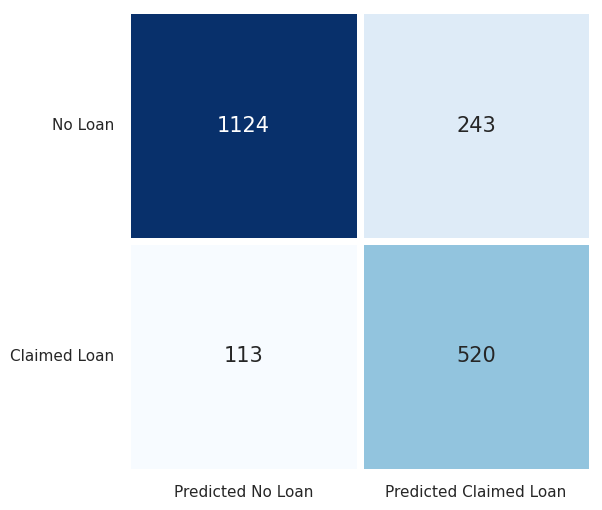

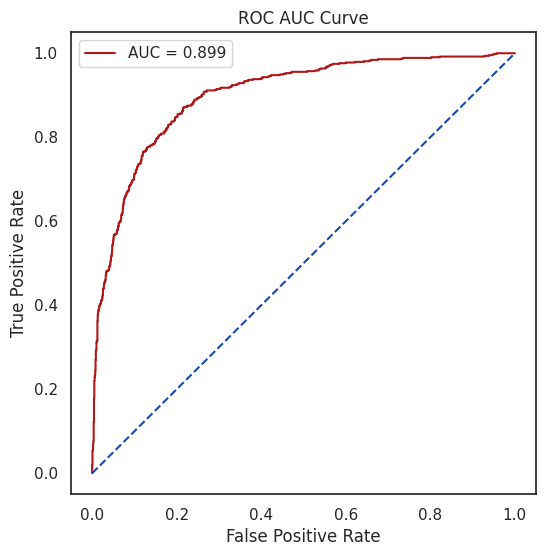

<Figure size 600x600 with 0 Axes>

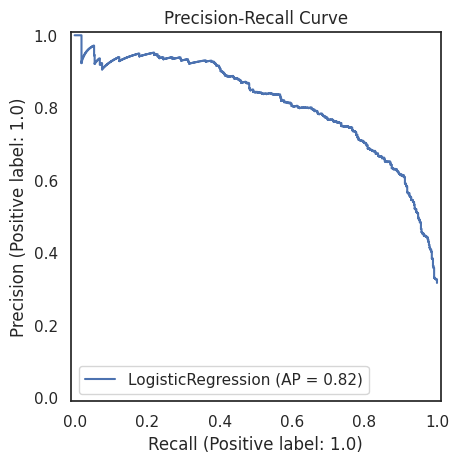

The test accuracy of logistic regression algorithm is  82.2 %


In [ ]:
accuracies = {}
classifier = LogisticRegression(C= 0.75, random_state= 0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(f'ROC AUC score: {roc_auc_score(y_test, y_prob)}')
print('Accuracy Score: ',accuracy_score(y_test, y_pred))

plt.figure(figsize = (6, 6))
sns.heatmap(cm, cmap = 'Blues', annot = True, fmt = 'd', linewidths = 5, cbar = False, annot_kws = {'fontsize': 15},
            yticklabels = ['No Loan', 'Claimed Loan'], xticklabels = ['Predicted No Loan', 'Predicted Claimed Loan'])
plt.yticks(rotation = 0)
plt.show()

acc = accuracy_score(y_test, y_pred)*100
accuracies['Logistic Regression'] = acc

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)

sns.set_theme(style = 'white')
plt.figure(figsize = (6, 6))
plt.plot(false_positive_rate,true_positive_rate, color = '#b01717', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1], linestyle = '--', color = '#174ab0')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.show()

plt.figure(figsize = (6, 6))
average_precision = average_precision_score(y_test, y_prob)
disp = PrecisionRecallDisplay.from_estimator(classifier, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.show()

print("The test accuracy of logistic regression algorithm is ",round(acc,1),"%")

#### **4.2.2 KNeighbors**

              precision    recall  f1-score   support

         0.0       0.87      0.82      0.84      1367
         1.0       0.65      0.73      0.69       633

    accuracy                           0.79      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.80      0.79      0.80      2000

ROC AUC score: 0.8457277210159122
Accuracy Score:  0.793


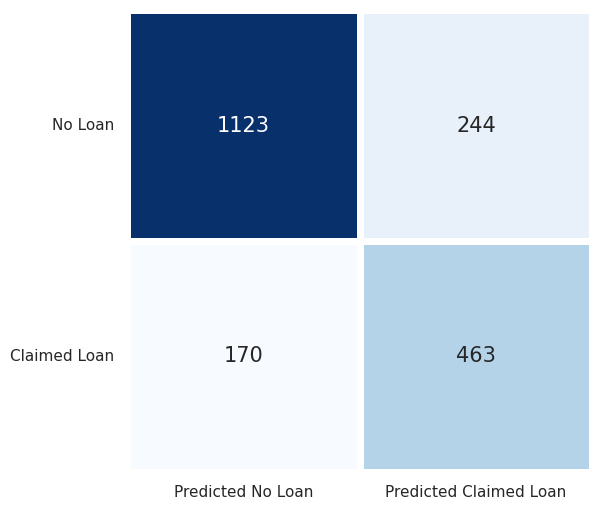

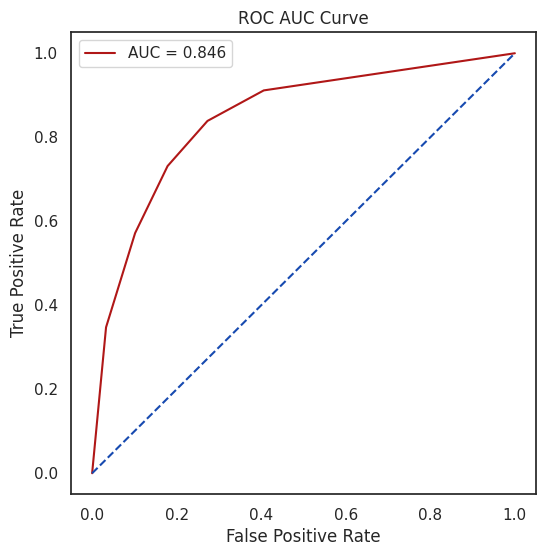

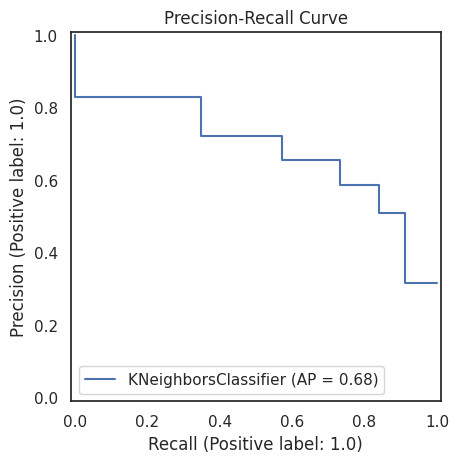

The test accuracy of Kneighbors algorithm is  79.3 %


In [ ]:
classifier = KNeighborsClassifier(metric= 'manhattan', n_neighbors= 5)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(f'ROC AUC score: {roc_auc_score(y_test, y_prob)}')
print('Accuracy Score: ',accuracy_score(y_test, y_pred))

plt.figure(figsize = (6, 6))
sns.heatmap(cm, cmap = 'Blues', annot = True, fmt = 'd', linewidths = 5, cbar = False, annot_kws = {'fontsize': 15},
            yticklabels = ['No Loan', 'Claimed Loan'], xticklabels = ['Predicted No Loan', 'Predicted Claimed Loan'])
plt.yticks(rotation = 0)
plt.show()

acc = accuracy_score(y_test, y_pred)*100
accuracies['KNeighbors'] = acc

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)

sns.set_theme(style = 'white')
plt.figure(figsize = (6, 6))
plt.plot(false_positive_rate,true_positive_rate, color = '#b01717', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1], linestyle = '--', color = '#174ab0')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.show()

average_precision = average_precision_score(y_test, y_prob)
disp = PrecisionRecallDisplay.from_estimator(classifier, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.show()

print("The test accuracy of Kneighbors algorithm is ",round(acc,1),"%")

#### **4.2.3 GaussianNB**

              precision    recall  f1-score   support

         0.0       0.89      0.73      0.80      1367
         1.0       0.58      0.81      0.68       633

    accuracy                           0.75      2000
   macro avg       0.74      0.77      0.74      2000
weighted avg       0.79      0.75      0.76      2000

ROC AUC score: 0.8488930569471556
Accuracy Score:  0.7535


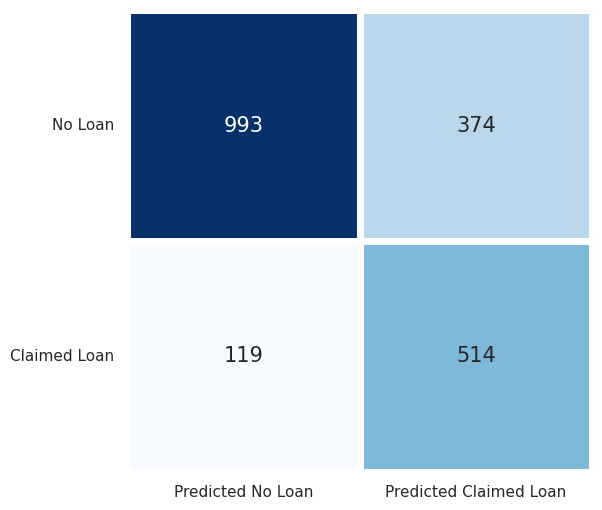

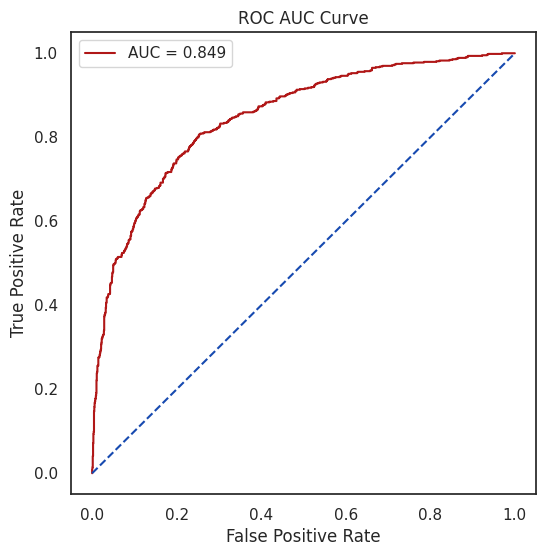

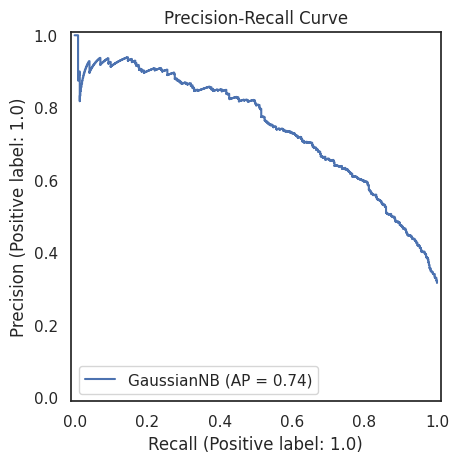

The test accuracy of GaussianNB algorithm is  75.3 %


In [ ]:
classifier = GaussianNB(var_smoothing= 1e-09)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(f'ROC AUC score: {roc_auc_score(y_test, y_prob)}')
print('Accuracy Score: ',accuracy_score(y_test, y_pred))

plt.figure(figsize = (6, 6))
sns.heatmap(cm, cmap = 'Blues', annot = True, fmt = 'd', linewidths = 5, cbar = False, annot_kws = {'fontsize': 15},
            yticklabels = ['No Loan', 'Claimed Loan'], xticklabels = ['Predicted No Loan', 'Predicted Claimed Loan'])
plt.yticks(rotation = 0)
plt.show()

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)

acc = accuracy_score(y_test, y_pred)*100
accuracies['GaussianNB'] = acc

sns.set_theme(style = 'white')
plt.figure(figsize = (6, 6))
plt.plot(false_positive_rate,true_positive_rate, color = '#b01717', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1], linestyle = '--', color = '#174ab0')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.show()

average_precision = average_precision_score(y_test, y_prob)
disp = PrecisionRecallDisplay.from_estimator(classifier, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.show()

print("The test accuracy of GaussianNB algorithm is ",round(acc,1),"%")

#### **4.2.4 Decision tree**

              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85      1367
         1.0       0.68      0.68      0.68       633

    accuracy                           0.80      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.80      0.80      0.80      2000

ROC AUC score: 0.7652237172531032
Accuracy Score:  0.796


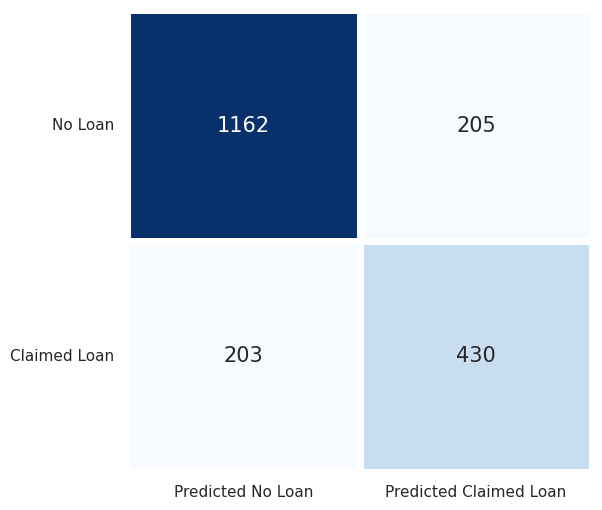

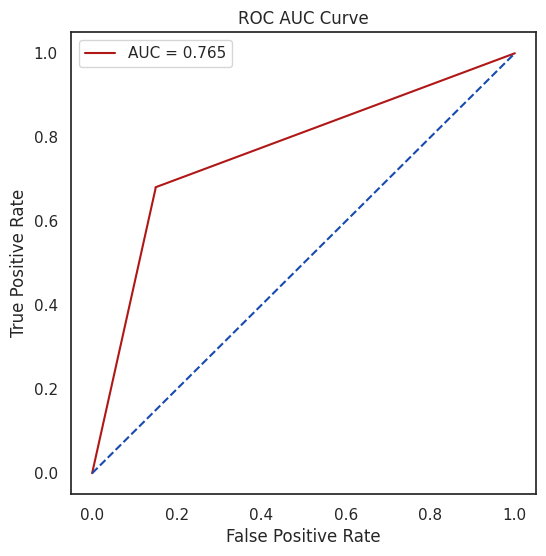

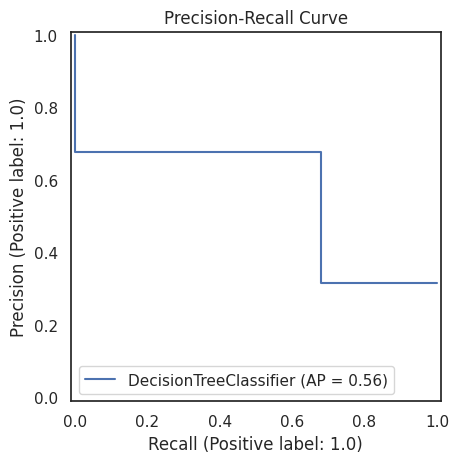

The test accuracy of Decision tree algorithm is  79.6 %


In [ ]:
classifier = DecisionTreeClassifier(criterion= 'entropy', random_state= 0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(f'ROC AUC score: {roc_auc_score(y_test, y_prob)}')
print('Accuracy Score: ',accuracy_score(y_test, y_pred))

plt.figure(figsize = (6, 6))
sns.heatmap(cm, cmap = 'Blues', annot = True, fmt = 'd', linewidths = 5, cbar = False, annot_kws = {'fontsize': 15},
            yticklabels = ['No Loan', 'Claimed Loan'], xticklabels = ['Predicted No Loan', 'Predicted Claimed Loan'])
plt.yticks(rotation = 0)
plt.show()

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)

acc = accuracy_score(y_test, y_pred)*100
accuracies['Decision Tree'] = acc



sns.set_theme(style = 'white')
plt.figure(figsize = (6, 6))
plt.plot(false_positive_rate,true_positive_rate, color = '#b01717', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1], linestyle = '--', color = '#174ab0')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.show()

average_precision = average_precision_score(y_test, y_prob)
disp = PrecisionRecallDisplay.from_estimator(classifier, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.show()

print("The test accuracy of Decision tree algorithm is ",round(acc,1),"%")

#### **4.2.5 Random Forest**

              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88      1367
         1.0       0.75      0.70      0.73       633

    accuracy                           0.83      2000
   macro avg       0.81      0.80      0.80      2000
weighted avg       0.83      0.83      0.83      2000

ROC AUC score: 0.9020566016149106
Accuracy Score:  0.832


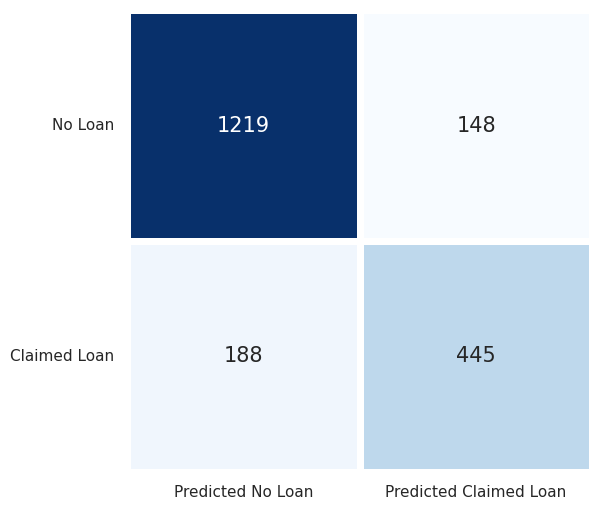

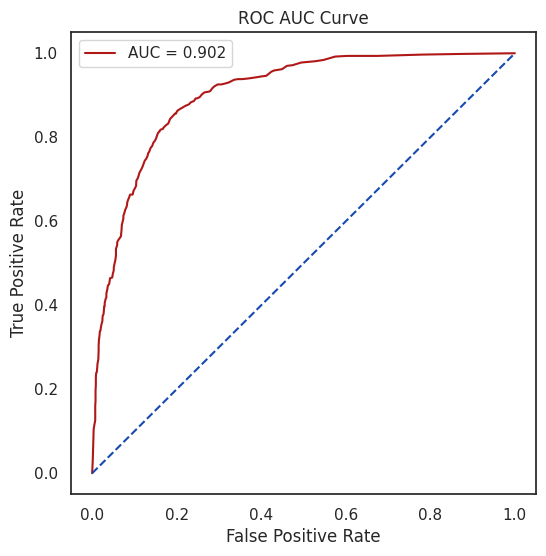

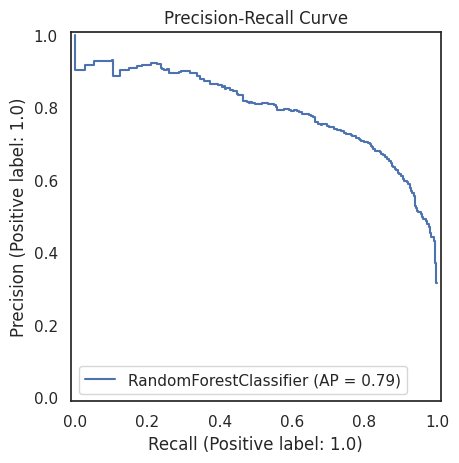

The test accuracy of Random forest algorithm is  83.2 %


In [ ]:
classifier = RandomForestClassifier(criterion= 'entropy', n_estimators= 150, random_state= 0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(f'ROC AUC score: {roc_auc_score(y_test, y_prob)}')
print('Accuracy Score: ',accuracy_score(y_test, y_pred))

plt.figure(figsize = (6, 6))
sns.heatmap(cm, cmap = 'Blues', annot = True, fmt = 'd', linewidths = 5, cbar = False, annot_kws = {'fontsize': 15},
            yticklabels = ['No Loan', 'Claimed Loan'], xticklabels = ['Predicted No Loan', 'Predicted Claimed Loan'])
plt.yticks(rotation = 0)
plt.show()

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)

acc = accuracy_score(y_test, y_pred)*100
accuracies['Random Forest'] = acc



sns.set_theme(style = 'white')
plt.figure(figsize = (6, 6))
plt.plot(false_positive_rate,true_positive_rate, color = '#b01717', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1], linestyle = '--', color = '#174ab0')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.show()

average_precision = average_precision_score(y_test, y_prob)
disp = PrecisionRecallDisplay.from_estimator(classifier, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.show()

print("The test accuracy of Random forest algorithm is ",round(acc,1),"%")

#### **4.2.6 AdaBoost**

              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88      1367
         1.0       0.74      0.77      0.75       633

    accuracy                           0.84      2000
   macro avg       0.81      0.82      0.82      2000
weighted avg       0.84      0.84      0.84      2000

ROC AUC score: 0.9144128527200048
Accuracy Score:  0.84


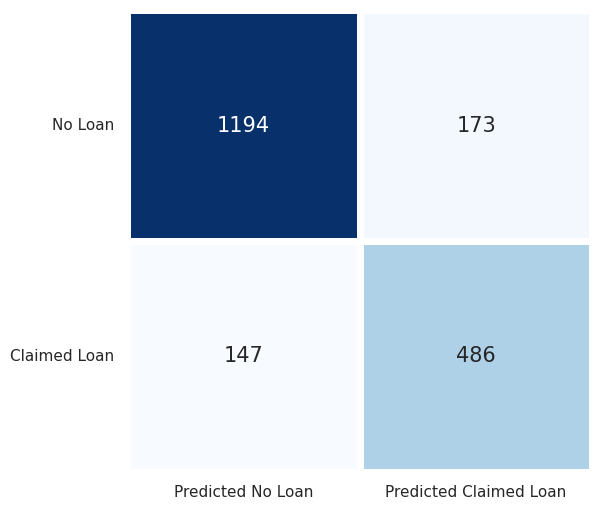

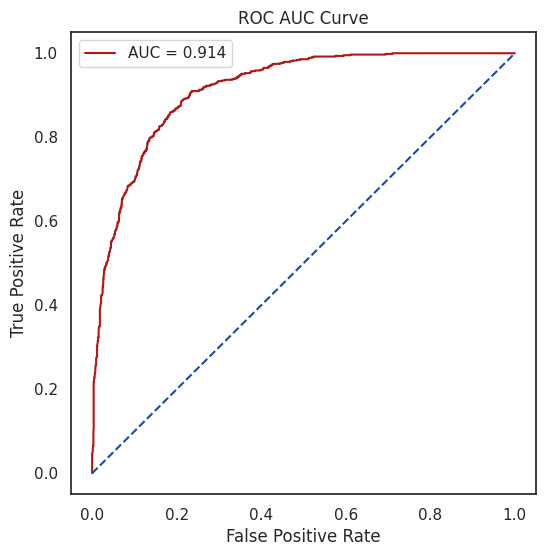

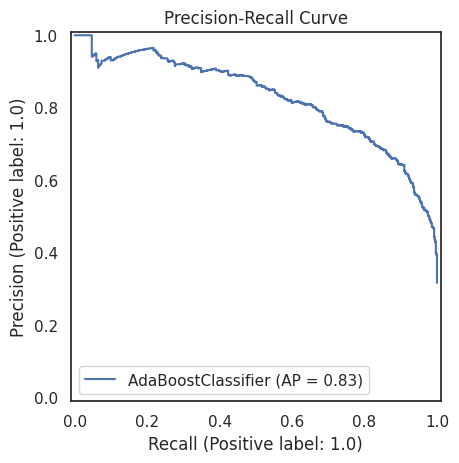

The test accuracy of AdaBoost algorithm is  84.0 %


In [ ]:
classifier = AdaBoostClassifier(algorithm= 'SAMME.R', learning_rate= 0.8, n_estimators= 100, random_state= 0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(f'ROC AUC score: {roc_auc_score(y_test, y_prob)}')
print('Accuracy Score: ',accuracy_score(y_test, y_pred))

plt.figure(figsize = (6, 6))
sns.heatmap(cm, cmap = 'Blues', annot = True, fmt = 'd', linewidths = 5, cbar = False, annot_kws = {'fontsize': 15},
            yticklabels = ['No Loan', 'Claimed Loan'], xticklabels = ['Predicted No Loan', 'Predicted Claimed Loan'])
plt.yticks(rotation = 0)
plt.show()

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)

acc = accuracy_score(y_test, y_pred)*100
accuracies['AdaBoost'] = acc

sns.set_theme(style = 'white')
plt.figure(figsize = (6, 6))
plt.plot(false_positive_rate,true_positive_rate, color = '#b01717', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1], linestyle = '--', color = '#174ab0')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.show()

average_precision = average_precision_score(y_test, y_prob)
disp = PrecisionRecallDisplay.from_estimator(classifier, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.show()

print("The test accuracy of AdaBoost algorithm is ",round(acc,1),"%")

#### **4.2.7 Gradient Boost**

              precision    recall  f1-score   support

         0.0       0.90      0.89      0.89      1367
         1.0       0.76      0.78      0.77       633

    accuracy                           0.85      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.85      0.85      0.85      2000

ROC AUC score: 0.9217004059812021
Accuracy Score:  0.8535


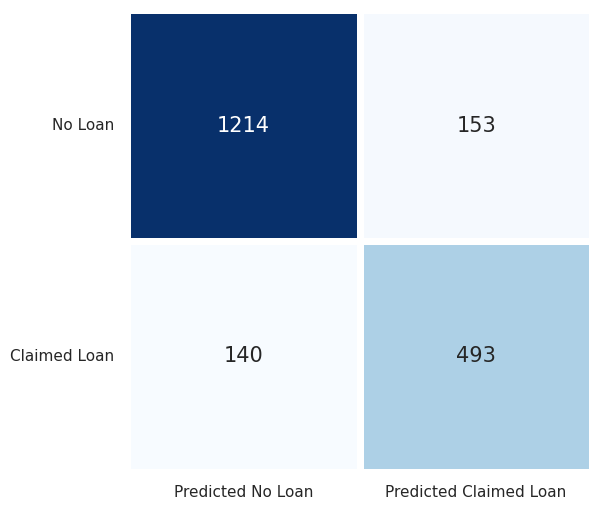

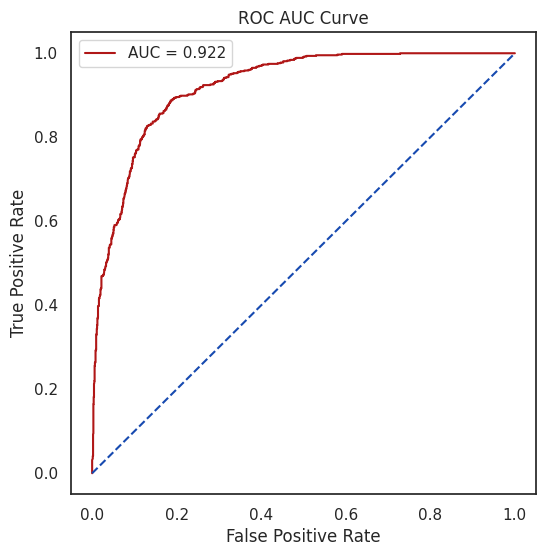

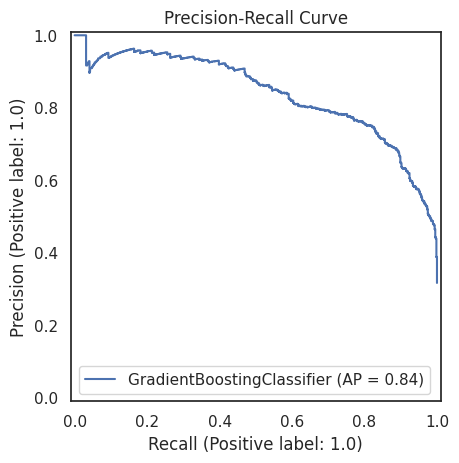

The test accuracy of Gradient Boost algorithm is  85.4 %


In [ ]:
classifier = GradientBoostingClassifier(criterion= 'friedman_mse', learning_rate= 0.1, loss= 'exponential', n_estimators= 100, random_state= 0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(f'ROC AUC score: {roc_auc_score(y_test, y_prob)}')
print('Accuracy Score: ',accuracy_score(y_test, y_pred))

plt.figure(figsize = (6, 6))
sns.heatmap(cm, cmap = 'Blues', annot = True, fmt = 'd', linewidths = 5, cbar = False, annot_kws = {'fontsize': 15},
            yticklabels = ['No Loan', 'Claimed Loan'], xticklabels = ['Predicted No Loan', 'Predicted Claimed Loan'])
plt.yticks(rotation = 0)
plt.show()

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)

acc = accuracy_score(y_test, y_pred)*100
accuracies['Gradient Boost'] = acc

sns.set_theme(style = 'white')
plt.figure(figsize = (6, 6))
plt.plot(false_positive_rate,true_positive_rate, color = '#b01717', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1], linestyle = '--', color = '#174ab0')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.show()

average_precision = average_precision_score(y_test, y_prob)
disp = PrecisionRecallDisplay.from_estimator(classifier, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.show()

print("The test accuracy of Gradient Boost algorithm is ",round(acc,1),"%")

#### **4.2.8 XGBoost**

              precision    recall  f1-score   support

         0.0       0.90      0.88      0.89      1367
         1.0       0.76      0.80      0.78       633

    accuracy                           0.85      2000
   macro avg       0.83      0.84      0.83      2000
weighted avg       0.86      0.85      0.86      2000

ROC AUC score: 0.9194763501215168
Accuracy Score:  0.855


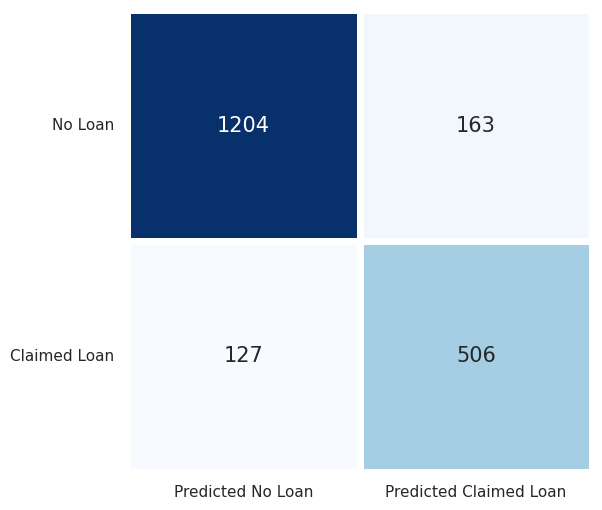

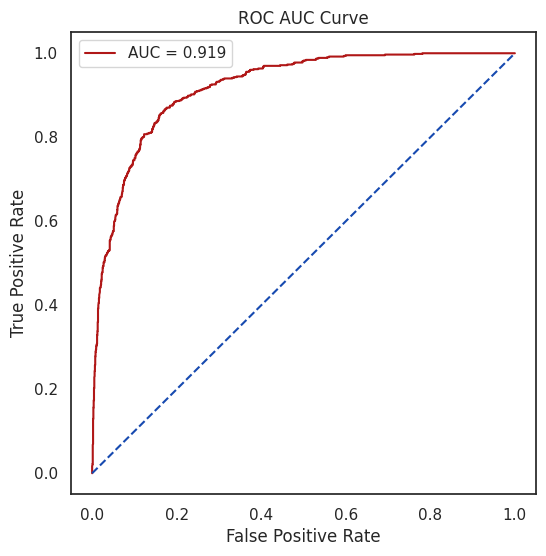

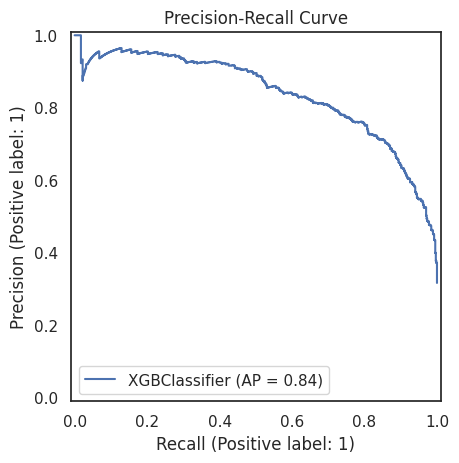

The test accuracy of XGBoost algorithm is  85.5 %


In [ ]:
classifier = XGBClassifier(eval_metric= 'error', learning_rate= 0.05)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(f'ROC AUC score: {roc_auc_score(y_test, y_prob)}')
print('Accuracy Score: ',accuracy_score(y_test, y_pred))

plt.figure(figsize = (6, 6))
sns.heatmap(cm, cmap = 'Blues', annot = True, fmt = 'd', linewidths = 5, cbar = False, annot_kws = {'fontsize': 15},
            yticklabels = ['No Loan', 'Claimed Loan'], xticklabels = ['Predicted No Loan', 'Predicted Claimed Loan'])
plt.yticks(rotation = 0)
plt.show()

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)

acc = accuracy_score(y_test, y_pred)*100
accuracies['XGBoost'] = acc

sns.set_theme(style = 'white')
plt.figure(figsize = (6, 6))
plt.plot(false_positive_rate,true_positive_rate, color = '#b01717', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1], linestyle = '--', color = '#174ab0')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.show()

average_precision = average_precision_score(y_test, y_prob)
disp = PrecisionRecallDisplay.from_estimator(classifier, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.show()

print("The test accuracy of XGBoost algorithm is ",round(acc,1),"%")

#### **4.2.9 SVC**

              precision    recall  f1-score   support

         0.0       0.90      0.83      0.87      1367
         1.0       0.69      0.81      0.74       633

    accuracy                           0.82      2000
   macro avg       0.80      0.82      0.80      2000
weighted avg       0.84      0.82      0.83      2000

ROC AUC score: 0.8881633308717906
Accuracy Score:  0.824


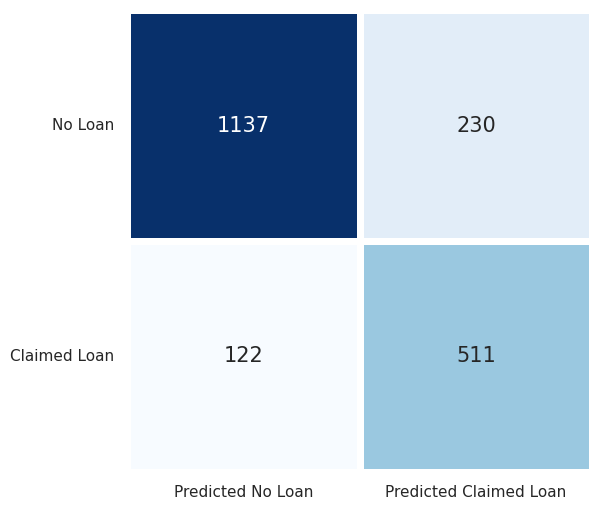

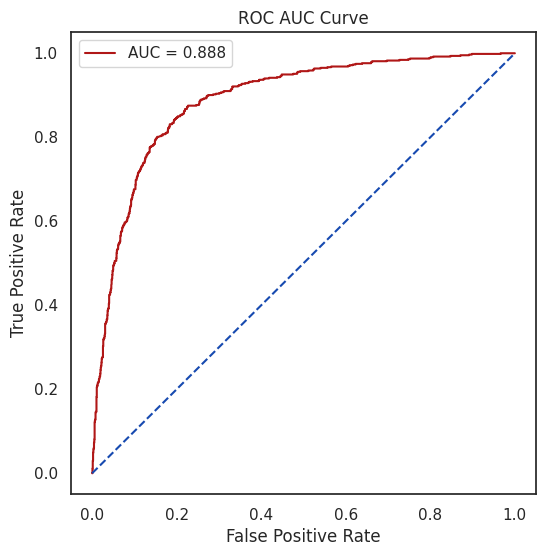

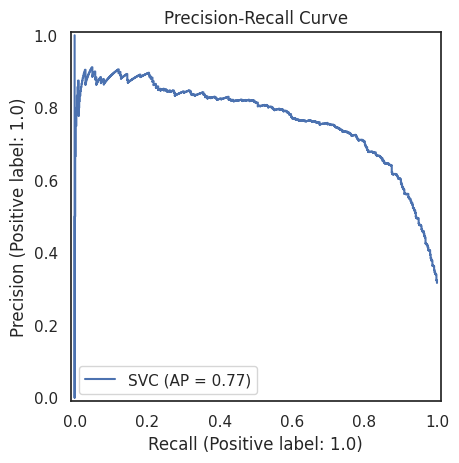

The test accuracy of SVC algorithm is  82.4 %


In [ ]:
classifier = SVC(C= 1, kernel= 'rbf', random_state= 0, probability=True)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(f'ROC AUC score: {roc_auc_score(y_test, y_prob)}')
print('Accuracy Score: ',accuracy_score(y_test, y_pred))

plt.figure(figsize = (6, 6))
sns.heatmap(cm, cmap = 'Blues', annot = True, fmt = 'd', linewidths = 5, cbar = False, annot_kws = {'fontsize': 15},
            yticklabels = ['No Loan', 'Claimed Loan'], xticklabels = ['Predicted No Loan', 'Predicted Claimed Loan'])
plt.yticks(rotation = 0)
plt.show()

acc = accuracy_score(y_test, y_pred)*100
accuracies['SVC'] = acc

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)

sns.set_theme(style = 'white')
plt.figure(figsize = (6, 6))
plt.plot(false_positive_rate,true_positive_rate, color = '#b01717', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1], linestyle = '--', color = '#174ab0')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.show()

average_precision = average_precision_score(y_test, y_prob)
disp = PrecisionRecallDisplay.from_estimator(classifier, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.show()

print("The test accuracy of SVC algorithm is ",round(acc,1),"%")

### **4.3 Comparing models**

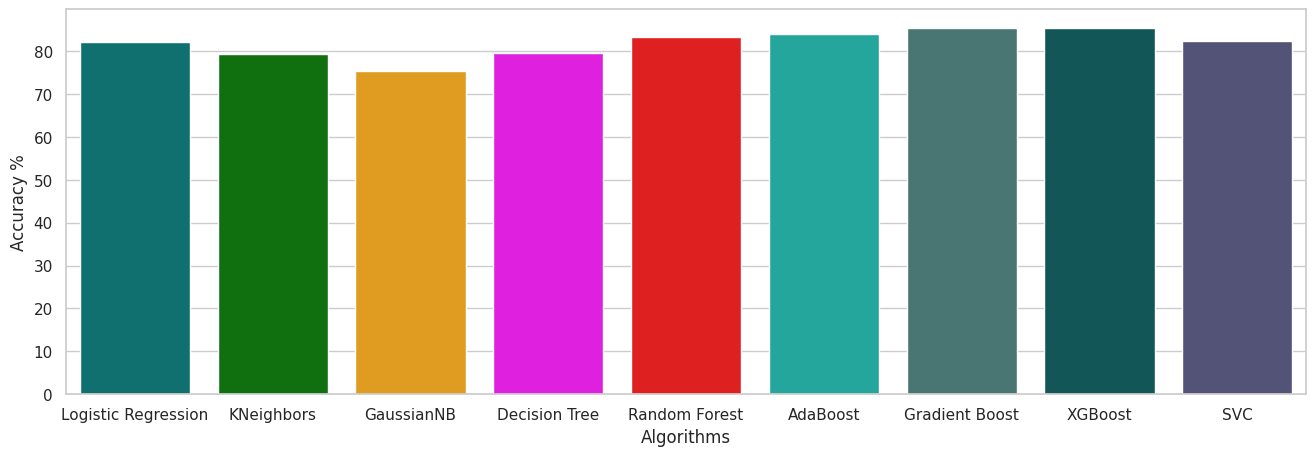

In [ ]:
colors = ["teal", "green", "orange", "magenta","red","#0FBBAE",'#417D7A','#066163','#4D4C7D']

sns.set_style("whitegrid")
plt.figure(figsize=(16,5))
plt.yticks(np.arange(0,100,10))
plt.ylabel("Accuracy %")
plt.xlabel("Algorithms")
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette=colors)
plt.show()

In [ ]:
df_tuned = pd.DataFrame(accuracies.items(), columns=['Model', 'Accuracy'])
df_tuned.sort_values(by= ['Accuracy'], inplace= True, ascending= False)
df_tuned

,Model,Accuracy
7,XGBoost,85.50
6,Gradient Boost,85.35
5,AdaBoost,84.00
4,Random Forest,83.20
8,SVC,82.40
0,Logistic Regression,82.20
3,Decision Tree,79.60
1,KNeighbors,79.30
2,GaussianNB,75.35


## **5. Summary**

After conducting significant data analysis, we experimented with various classification models to see how well they performed on the dataset. With accuracy, ROC, precision, and recall score, we obtained quite decent results.
We have used SMOTE oversampling method for imbalanced classification data. *But we didn't stop there; using Grid Search, we fine-tuned the hyperparamters and viewed the classification report, which included ROC AUC and Precision-Recall curves for various models.
With that, we came to conclusion that Random Forest, SVC, and The Boosting Algoritm (AdaBoost, Gradient Boost, XGBoost) are models which are best fit for our dataset.
After Tuning the Hyperparameter XGBoost algorithm has the Highest Accuracy of exactly 85.5% & AUC of 0.919.